# Flight delays - baseline and metric choice

Two things have to exist before a gradient boosted model is allowed to look impressive: a
number for it to beat, and a metric that cannot be gamed by predicting "on time" for every
flight.

Three references are fitted here on the same features and the same time split - a
majority-class dummy, a stratified dummy and logistic regression. The feature matrix comes
from `flight_delay.transform.features` (built in `FE.ipynb`); the split, the linear pipeline
and the metric bundle live in `flight_delay.training`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from flight_delay.training import baseline as B
from flight_delay.training import evaluate as E
from flight_delay.training import split as S
from flight_delay.transform.features import build_features

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA = PROJECT_ROOT / "data" / "processed"

## Features and split

`build_features` returns `(X, y, flight_date)` from the raw BTS frame. The date comes back
separately because it drives the split and must never become a feature. `check_columns_covered`
asserts that every column of `X` was deliberately assigned to one of the three column lists in
`baseline.py`; without it, a feature added later would quietly sit out the baseline comparison
and flatter the tree by exactly its own value.

In [2]:
flights = pd.read_parquet(DATA)
X, y, flight_date = build_features(flights)
B.check_columns_covered(X)

print(f"X: {X.shape} | y positive rate: {y.mean():.4f}")

X: (6965247, 20) | y positive rate: 0.2082


In [3]:
train, test = S.time_split(flight_date)
X_train, y_train = X[train], y[train]
X_test, y_test = X[test], y[test]

S.describe_split(y, train, test, flight_date)

,side,count,date_range,positive_rate
0,train,5808482,"(2024-01-01 00:00:00, 2024-10-31 00:00:00)",0.213885
1,test,1156765,"(2024-11-01 00:00:00, 2024-12-31 00:00:00)",0.179484


Ten months to train on, November and December to test on: the model predicts forward in time,
so the split does too. The last training day falls strictly before the first test day, which is
the off-by-one guard.

The positive rates do not match - 0.2139 on train against 0.1795 on test - so the test months
are the *easier* stretch of the year, the autumn dip from `EDA2.ipynb` outweighing winter. Two
consequences: every score below is mildly optimistic compared to, say, a July test set, and the
no-skill reference for PR-AUC is 0.1795 rather than the global 0.2082.

## Baselines without a model

`most_frequent` answers "on time" for every flight. `stratified` guesses at the training base
rate. Neither looks at `X`, but both are handed the real matrix anyway - `DummyClassifier`
ignores its values, and a placeholder array would only be one more thing to explain.

In [4]:
results: dict[str, dict[str, float]] = {}

for strategy in ("most_frequent", "stratified"):
    dummy = DummyClassifier(strategy=strategy, random_state=42)
    dummy.fit(X_train, y_train)
    results[strategy] = E.evaluate_binary(y_test, dummy.predict_proba(X_test)[:, 1])

E.compare(results, decimals=5)

,roc_auc,pr_auc,no_skill_pr,precision,recall,f1,accuracy
most_frequent,0.50000,0.17948,0.17948,0.0000,0.000,0.00000,0.82052
stratified,0.50008,0.17951,0.17948,0.1796,0.214,0.19529,0.68347


The first row is the whole argument for the metric choice in one line: 82% accuracy, zero
delays found.

It also pins down where "no skill" sits, and which dummy puts it there matters. A constant
score ranks every flight identically, so `most_frequent` lands on ROC-AUC 0.5 and PR-AUC equal
to the positive rate of the evaluated set, on the nose. `stratified` draws a class per row
instead, so it scatters *around* those references rather than onto them: 0.50008 and 0.17951
here, the latter a hair above the floor it is often assumed to define, and 0.1503 against a
floor of 0.1511 when the same code ran on January alone. Its row is kept for a different
reason - recall 0.214 at precision 0.180, a model that "finds" a fifth of the delays while
being wrong four times out of five whenever it flags one. Recall on its own is not a result.

## Logistic regression

The linear model cannot eat `X` as it stands. `Origin` and `Dest` carry roughly 350 levels
each, and `CRSDepTime` packs HHMM into an integer, where 1259 to 1300 is a jump of 41. The
column lists in `baseline.py` cut the 20 features down to 8 numeric and 4 one-hot columns, and
the airport, route and carrier signal reaches the model through the smoothed history features
from `FE.ipynb` instead - which is what lets a linear model use that information at all.

Everything sits in one `Pipeline` so that the scaler is fitted on the training months alone.

In [5]:
pipe = B.make_baseline_pipeline()
pipe.fit(X_train, y_train)

score = pipe.predict_proba(X_test)[:, 1]
results["logistic"] = E.evaluate_binary(y_test, score)

E.compare(results, decimals=5)

,roc_auc,pr_auc,no_skill_pr,precision,recall,f1,accuracy
most_frequent,0.50000,0.17948,0.17948,0.00000,0.00000,0.00000,0.82052
stratified,0.50008,0.17951,0.17948,0.17960,0.21400,0.19529,0.68347
logistic,0.61411,0.24581,0.17948,0.33584,0.01461,0.02801,0.81795


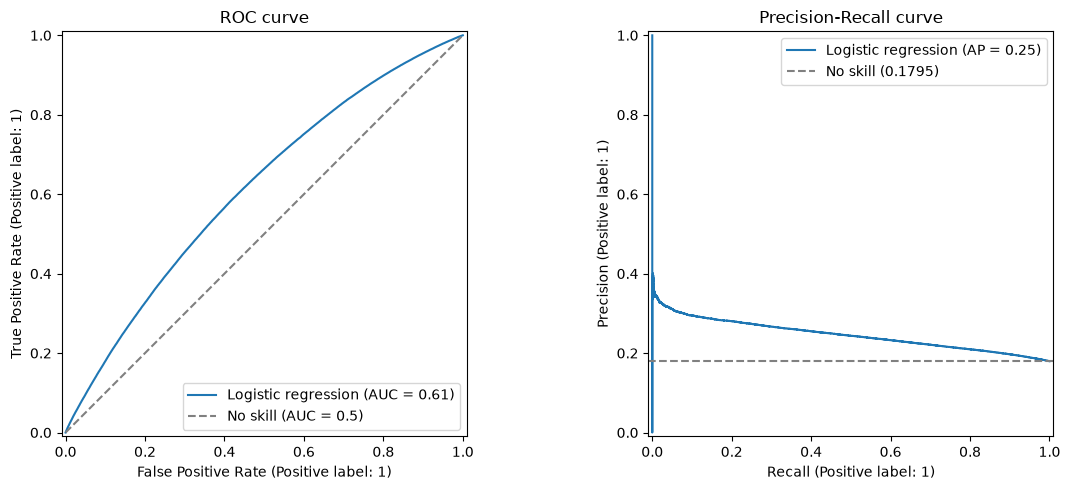

In [ ]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, score, name="Logistic regression", ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill (AUC = 0.5)")
ax_roc.set_title("ROC curve")
ax_roc.legend(loc="lower right")

# On PR the no-skill line is the positive rate of the evaluated set, not 0.5.
base_rate = y_test.mean()
PrecisionRecallDisplay.from_predictions(y_test, score, name="Logistic regression", ax=ax_pr)
ax_pr.axhline(base_rate, linestyle="--", color="gray", label=f"No skill ({base_rate:.4f})")
ax_pr.set_title("Precision-Recall curve")
ax_pr.legend(loc="upper right")

fig.tight_layout()
plt.show()

## What the numbers say

**The linear model carries real signal, and not much of it.** PR-AUC 0.2458 against a no-skill
floor of 0.1795 is a lift of about 1.37x. That is a ranking, not a decision rule: where the
model is most confident it is right roughly a third of the time (precision 0.336 at threshold
0.5) against a base rate of 0.18. Enough to order a dispatcher's watchlist, not enough to page
anyone automatically.

**Accuracy is now formally disqualified.** Logistic regression scores 0.81795 and the
majority-class dummy 0.82052: the model with ROC-AUC 0.614 is *less accurate* than the one that
never predicts a delay at all. Everything to the right of `no_skill_pr` in the table moves with
the threshold; only the two AUCs compare models.

**Recall 0.0146 is the threshold's fault, not the model's.** At a base rate of 0.18 the fitted
probabilities rarely cross 0.5, so the default threshold flags almost nothing. The curve above
is what the ranking can actually do at other operating points, and choosing one of them is a
statement about the price of a false alarm against the price of a missed delay - a decision for
the evaluation notebook, not a side effect of a constructor argument.

**The bar for gradient boosting is PR-AUC 0.2458, not ROC-AUC 0.6141.** ROC-AUC is the
friendlier headline and the wrong yardstick here: with an on-time majority of four to one, the
false-positive rate stays flattering however many false alarms are raised. If XGBoost cannot
clear that PR-AUC by a margin worth the hyperparameters, the training time and the loss of a
readable coefficient table, then the honest deliverable is a linear model on 12 columns.

Two facts about this baseline travel forward as constraints rather than results: the test
months are the easy end of the year, so nothing here transfers unchanged to a summer test set,
and the four history features are doing most of the work, because every high-cardinality column
was dropped before the linear model could see it.